# Finetuning des modèles — Prédiction du prix immobilier
## Notebook 03 : Finetuning et Sélection du Meilleur Modèle

### Plan du Notebook 03

**ÉTAPE 1 : Chargement des Modèles Baseline**

* 1.1 — Chargement des pipelines baseline depuis `models/baseline.joblib`

**Nettoyage amélioré et Feature Engineering**

* 9.2 — Filtrage des transactions aberrantes (ventes ≤ $1 000, transferts familiaux)
* 9.1 — Feature engineering avancé (ratio surfaces, âge bâtiment, interactions)

**ÉTAPE 2 : Finetuning — Régression Linéaire Régularisée**

* 2.1 — GridSearchCV (Ridge / Lasso / ElasticNet)
* 2.2 — RandomizedSearchCV sur les paramètres de régularisation
* 2.3 — Analyse visuelle de l'espace des hyperparamètres

**ÉTAPE 3 : Finetuning — XGBoost**

* 3.1 — RandomizedSearchCV sur les hyperparamètres principaux

**ÉTAPE 4 : Finetuning — Random Forest**

* 4.1 — RandomizedSearchCV sur les hyperparamètres principaux

**ÉTAPE 9.5 : Optimisation Bayésienne (Optuna)**

* 9.5 — Optuna sur XGBoost et Random Forest (50 trials chacun)

**ÉTAPE 9.3 : Stacking / Blending de Modèles**

* 9.3 — Combinaison Ridge + XGBoost Optuna + RF Optuna → méta-apprenant Ridge

**ÉTAPE 5 : Validation Croisée Imbriquée (Nested CV)**

* 5.1 — Estimation robuste de la performance de généralisation (5 folds externes × 5 folds internes)

**ÉTAPE 6 : Comparaison Baseline vs Modèles Finetuned**

* 6.1 — Prédictions Out-of-Fold sur le jeu d'entraînement
* 6.2 — Comparaison des performances (RMSE, MAE, R², MAPE)

**ÉTAPE 7 : Analyse des Résultats**

* 7.1 — Distribution des erreurs (résidus)
* 7.2 — Analyse des prédictions extrêmes
* 7.3 — Importance des variables (XGBoost / Random Forest)
* 9.4 — Segmentation prix standard vs luxe

**ÉTAPE 8 : Évaluation Finale et Export du Modèle**

* 8.1 — Sélection du meilleur modèle (incluant Optuna + Stacking)
* 8.2 — Évaluation finale sur le jeu de test
* 8.3 — Export du pipeline final pour production

**Synthèse Générale du Notebook 03**

In [ ]:
"""
Configuration de l'environnement — Prédiction du prix immobilier
===================================================
Imports et configuration pour le finetuning des modèles de régression.
"""

import os
import psutil
import sys
import multiprocessing

# Nombre de cœurs disponibles
num_cores = multiprocessing.cpu_count()
print(f"Nombre de cœurs disponibles : {num_cores}")

# Nombre total de coeurs physiques
num_physical_cores = psutil.cpu_count(logical=True)

# Laisser un cœur libre pour le système
num_cores_to_use = max(1, num_physical_cores - 1)

# Manipulation de données
import pandas as pd
import numpy as np
import warnings
import joblib
warnings.filterwarnings('ignore')

# Statistiques et distributions
from scipy.stats import loguniform, randint, uniform

# Visualisation
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

# Modèles de régression
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from xgboost import XGBRegressor

# Prétraitement et pipeline
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    cross_validate, cross_val_predict, KFold
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Métriques de régression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Optimisation Bayésienne
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Seed pour la reproductibilité
RANDOM_STATE = 1204

print(" Imports chargés avec succès (+ Optuna, StackingRegressor)")

Nombre de cœurs disponibles : 16
 Imports chargés avec succès (+ Optuna, StackingRegressor)


In [21]:
# ============================================================
# Chargement du dataset brut
# ============================================================
df = pd.read_csv("..\\data\\nyc-rolling-sales.csv")
print(f" Dataset importé : {df.shape[0]} lignes et {df.shape[1]} colonnes\n")

# ============================================================
# Séparation features / cible
# ============================================================
Target = "SALE PRICE"

# Conversion de la cible en numérique (valeurs comme " - " → NaN)
df[Target] = pd.to_numeric(df[Target], errors="coerce")

X = df.drop(columns=[Target])
y = df[Target]

# Séparation en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# --- Limitation du jeu d'entraînement à 10 000 lignes max ---
MAX_TRAIN = 10_000
if len(X_train) > MAX_TRAIN:
    X_train = X_train.sample(n=MAX_TRAIN, random_state=RANDOM_STATE)
    y_train = y_train.loc[X_train.index]

# --- Affichage des dimensions ---
print("\n" + "=" * 70)
print("  DIMENSIONS DES DONNÉES")
print("=" * 70)
print(f"  Variables explicatives (X_train) : {X_train.shape}")
print(f"  Variable cible         (y_train) : {y_train.shape}")
print("-" * 70)
print(f"  Variables explicatives (X_test)  : {X_test.shape}")
print(f"  Variable cible         (y_test)  : {y_test.shape}")
print("=" * 70)

 Dataset importé : 84548 lignes et 22 colonnes


  DIMENSIONS DES DONNÉES
  Variables explicatives (X_train) : (10000, 21)
  Variable cible         (y_train) : (10000,)
----------------------------------------------------------------------
  Variables explicatives (X_test)  : (16910, 21)
  Variable cible         (y_test)  : (16910,)


In [22]:
# Identification des types de variables sur le jeu d'entraînement
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f" {len(cat_cols)} variables catégorielles : {cat_cols}\n")
print(f" {len(num_cols)} variables numériques    : {num_cols}\n")
print(f" Total : {len(cat_cols) + len(num_cols)} variables")

 11 variables catégorielles : ['NEIGHBORHOOD', 'BUILDING CLASS CATEGORY', 'TAX CLASS AT PRESENT', 'EASE-MENT', 'BUILDING CLASS AT PRESENT', 'ADDRESS', 'APARTMENT NUMBER', 'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'BUILDING CLASS AT TIME OF SALE', 'SALE DATE']

 10 variables numériques    : ['Unnamed: 0', 'BOROUGH', 'BLOCK', 'LOT', 'ZIP CODE', 'RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS', 'YEAR BUILT', 'TAX CLASS AT TIME OF SALE']

 Total : 21 variables


In [23]:
# ============================================================
# ÉTAPE 1.1 — Chargement des pipelines baseline depuis models/
# ============================================================
pipe_lr_baseline = joblib.load("../models/baseline_lr.joblib")
pipe_xgb_baseline = joblib.load("../models/baseline_xgb.joblib")
pipe_rf_baseline = joblib.load("../models/baseline_rf.joblib")

print(" Modèles baseline chargés :")
print("   baseline_lr.joblib  — Régression Linéaire")
print("   baseline_xgb.joblib — XGBoost")
print("   baseline_rf.joblib  — Random Forest")

 Modèles baseline chargés :
   baseline_lr.joblib  — Régression Linéaire
   baseline_xgb.joblib — XGBoost
   baseline_rf.joblib  — Random Forest


In [24]:
# ============================================================
# Nettoyage des données (même traitement que Notebook 02)
# ============================================================
mask_train = y_train.notna() & (y_train > 0)
mask_test = y_test.notna() & (y_test > 0)

X_train_clean = X_train[mask_train].reset_index(drop=True)
y_train_clean = y_train[mask_train].reset_index(drop=True)
X_test_clean = X_test[mask_test].reset_index(drop=True)
y_test_clean = y_test[mask_test].reset_index(drop=True)

print(f" Après suppression NaN/0 : Train {len(X_train_clean)} | Test {len(X_test_clean)}")

# ============================================================
# 9.2 — Filtrage des transactions aberrantes
# ============================================================
# Seuil minimal : exclure les ventes ≤ $1 000 (transferts familiaux, $0, $10...)
PRIX_MIN = 1_000
mask_aberrant_train = y_train_clean > PRIX_MIN
mask_aberrant_test = y_test_clean > PRIX_MIN

n_removed_train = (~mask_aberrant_train).sum()
n_removed_test = (~mask_aberrant_test).sum()

X_train_clean = X_train_clean[mask_aberrant_train].reset_index(drop=True)
y_train_clean = y_train_clean[mask_aberrant_train].reset_index(drop=True)
X_test_clean = X_test_clean[mask_aberrant_test].reset_index(drop=True)
y_test_clean = y_test_clean[mask_aberrant_test].reset_index(drop=True)

print(f" Filtrage aberrants (prix ≤ ${PRIX_MIN:,}) : {n_removed_train} train / {n_removed_test} test supprimés")
print(f" Après filtrage : Train {len(X_train_clean)} | Test {len(X_test_clean)}")

# Winsorization (P1-P99)
Q1 = y_train_clean.quantile(0.01)
Q99 = y_train_clean.quantile(0.99)
y_train_clean = y_train_clean.clip(lower=Q1, upper=Q99)
y_test_clean = y_test_clean.clip(lower=Q1, upper=Q99)

# Transformation log1p de la cible
y_train_log = np.log1p(y_train_clean)
y_test_log = np.log1p(y_test_clean)

print(f" Winsorization appliquée (P1=${Q1:,.0f} — P99=${Q99:,.0f})")
print(f" Transformation log1p appliquée")

# ============================================================
# 9.1 — Feature Engineering Avancé
# ============================================================
def feature_engineering(df):
    """Crée des features supplémentaires à partir des colonnes existantes."""
    df = df.copy()

    # Conversion des surfaces en numérique
    for col in ['LAND SQUARE FEET', 'GROSS SQUARE FEET']:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

    # Prix au pied carré (sera rempli par imputation plus tard)
    gross_sf = df['GROSS SQUARE FEET'].replace(0, np.nan)
    land_sf = df['LAND SQUARE FEET'].replace(0, np.nan)

    # Ratio surface bâtie / surface terrain
    df['RATIO_GROSS_LAND'] = gross_sf / land_sf

    # Âge du bâtiment (année courante - année de construction)
    current_year = 2026
    df['BUILDING_AGE'] = current_year - df['YEAR BUILT']
    df.loc[df['YEAR BUILT'] == 0, 'BUILDING_AGE'] = np.nan

    # Indicateur : bâtiment récent (< 20 ans)
    df['IS_NEW_BUILD'] = (df['BUILDING_AGE'] < 20).astype(int)

    # Total des unités = résidentielles + commerciales (vérification de cohérence)
    df['UNITS_RATIO_RES'] = df['RESIDENTIAL UNITS'] / df['TOTAL UNITS'].replace(0, np.nan)

    # Indicateur : bien purement résidentiel
    df['IS_RESIDENTIAL'] = (df['COMMERCIAL UNITS'] == 0).astype(int)

    # Interactions : surface × borough
    df['GROSS_SF_x_BOROUGH'] = gross_sf.fillna(0) * df['BOROUGH']

    return df

X_train_clean = feature_engineering(X_train_clean)
X_test_clean = feature_engineering(X_test_clean)

# Mise à jour des listes de colonnes
new_num_features = ['RATIO_GROSS_LAND', 'BUILDING_AGE', 'IS_NEW_BUILD',
                    'UNITS_RATIO_RES', 'IS_RESIDENTIAL', 'GROSS_SF_x_BOROUGH']
num_cols_ext = num_cols + new_num_features

print(f" Feature engineering : {len(new_num_features)} nouvelles features créées")
print(f"   → {new_num_features}")

# ============================================================
# Construction du preprocessor (étendu avec nouvelles features)
# ============================================================
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, max_categories=30))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols_ext),
        ('cat', categorical_transformer, cat_cols)
    ]
)

# Cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f" Preprocessor construit : {len(num_cols_ext)} num + {len(cat_cols)} cat")

# ============================================================
# Fonction d'évaluation (répliquée depuis Notebook 02)
# ============================================================
def evaluate_regression(y_true_log, y_pred_log, y_true_orig, label=""):
    """Calcule et affiche les métriques de régression."""
    rmse = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    mae = mean_absolute_error(y_true_log, y_pred_log)
    r2 = r2_score(y_true_log, y_pred_log)
    y_pred_orig = np.expm1(y_pred_log)
    mask = y_true_orig > 0
    mape = np.mean(np.abs((y_true_orig[mask] - y_pred_orig[mask]) / y_true_orig[mask])) * 100

    print(f"\n  {label}")
    print(f"  {'─' * 40}")
    print(f"  RMSE (log)  : {rmse:.4f}")
    print(f"  MAE  (log)  : {mae:.4f}")
    print(f"  R²          : {r2:.4f}")
    print(f"  MAPE (%)    : {mape:.2f}%")
    return {'RMSE': rmse, 'MAE': mae, 'R²': r2, 'MAPE': mape}

print(" Fonction evaluate_regression définie")

 Après suppression NaN/0 : Train 7110 | Test 12007
 Filtrage aberrants (prix ≤ $1,000) : 108 train / 238 test supprimés
 Après filtrage : Train 7002 | Test 11769
 Winsorization appliquée (P1=$25,000 — P99=$12,921,358)
 Transformation log1p appliquée
 Feature engineering : 6 nouvelles features créées
   → ['RATIO_GROSS_LAND', 'BUILDING_AGE', 'IS_NEW_BUILD', 'UNITS_RATIO_RES', 'IS_RESIDENTIAL', 'GROSS_SF_x_BOROUGH']
 Preprocessor construit : 16 num + 11 cat
 Fonction evaluate_regression définie


---

## ÉTAPE 2 : Finetuning — Régression Linéaire Régularisée

### 2.1 — GridSearchCV (Ridge / Lasso / ElasticNet)

In [25]:
# ============================================================
# 2.1 — GridSearchCV : Ridge, Lasso, ElasticNet
# ============================================================
print("=" * 70)
print("  GRIDSEARCHCV — RÉGRESSION LINÉAIRE RÉGULARISÉE")
print("=" * 70)

# --- Ridge ---
pipe_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(random_state=RANDOM_STATE))
])

param_grid_ridge = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
}

grid_ridge = GridSearchCV(
    pipe_ridge, param_grid_ridge, cv=cv,
    scoring='r2', n_jobs=-1, verbose=0
)
grid_ridge.fit(X_train_clean, y_train_log)

print(f"\n Ridge — Meilleurs paramètres : {grid_ridge.best_params_}")
print(f"   Meilleur R² (CV) : {grid_ridge.best_score_:.4f}")

# --- Lasso ---
pipe_lasso = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(random_state=RANDOM_STATE, max_iter=10000))
])

param_grid_lasso = {
    'regressor__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
}

grid_lasso = GridSearchCV(
    pipe_lasso, param_grid_lasso, cv=cv,
    scoring='r2', n_jobs=-1, verbose=0
)
grid_lasso.fit(X_train_clean, y_train_log)

print(f"\n Lasso — Meilleurs paramètres : {grid_lasso.best_params_}")
print(f"   Meilleur R² (CV) : {grid_lasso.best_score_:.4f}")

# --- ElasticNet ---
pipe_enet = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', ElasticNet(random_state=RANDOM_STATE, max_iter=10000))
])

param_grid_enet = {
    'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
    'regressor__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

grid_enet = GridSearchCV(
    pipe_enet, param_grid_enet, cv=cv,
    scoring='r2', n_jobs=-1, verbose=0
)
grid_enet.fit(X_train_clean, y_train_log)

print(f"\n ElasticNet — Meilleurs paramètres : {grid_enet.best_params_}")
print(f"   Meilleur R² (CV) : {grid_enet.best_score_:.4f}")

# --- Comparaison ---
print(f"\n{'─' * 50}")
best_linear = max(
    [('Ridge', grid_ridge), ('Lasso', grid_lasso), ('ElasticNet', grid_enet)],
    key=lambda x: x[1].best_score_
)
print(f" Meilleur modèle linéaire régularisé : {best_linear[0]} (R² CV = {best_linear[1].best_score_:.4f})")

  GRIDSEARCHCV — RÉGRESSION LINÉAIRE RÉGULARISÉE

 Ridge — Meilleurs paramètres : {'regressor__alpha': 0.1}
   Meilleur R² (CV) : 0.3782

 Lasso — Meilleurs paramètres : {'regressor__alpha': 0.0001}
   Meilleur R² (CV) : 0.3995

 ElasticNet — Meilleurs paramètres : {'regressor__alpha': 0.001, 'regressor__l1_ratio': 0.3}
   Meilleur R² (CV) : 0.3877

──────────────────────────────────────────────────
 Meilleur modèle linéaire régularisé : Lasso (R² CV = 0.3995)


### 2.2 — RandomizedSearchCV sur les paramètres de régularisation

Exploration plus fine de l'espace des hyperparamètres avec des distributions continues.

In [26]:
# ============================================================
# 2.2 — RandomizedSearchCV : Exploration fine de l'espace
# ============================================================
print("=" * 70)
print("  RANDOMIZEDSEARCHCV — RÉGULARISATION FINE")
print("=" * 70)

# RandomizedSearchCV sur ElasticNet (le plus flexible)
param_dist_enet = {
    'regressor__alpha': loguniform(1e-4, 1e2),
    'regressor__l1_ratio': uniform(0.0, 1.0)
}

random_enet = RandomizedSearchCV(
    pipe_enet, param_dist_enet,
    n_iter=100, cv=cv, scoring='r2',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
random_enet.fit(X_train_clean, y_train_log)

print(f"\n ElasticNet (RandomizedSearch) — Meilleurs paramètres :")
print(f"   alpha    = {random_enet.best_params_['regressor__alpha']:.6f}")
print(f"   l1_ratio = {random_enet.best_params_['regressor__l1_ratio']:.4f}")
print(f"   R² (CV)  = {random_enet.best_score_:.4f}")

# RandomizedSearchCV sur Ridge
param_dist_ridge = {
    'regressor__alpha': loguniform(1e-3, 1e4)
}

random_ridge = RandomizedSearchCV(
    pipe_ridge, param_dist_ridge,
    n_iter=100, cv=cv, scoring='r2',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
random_ridge.fit(X_train_clean, y_train_log)

print(f"\n Ridge (RandomizedSearch) — Meilleurs paramètres :")
print(f"   alpha   = {random_ridge.best_params_['regressor__alpha']:.6f}")
print(f"   R² (CV) = {random_ridge.best_score_:.4f}")

# Sélection du meilleur modèle linéaire finetuné
best_linear_random = max(
    [('Ridge', random_ridge), ('ElasticNet', random_enet)],
    key=lambda x: x[1].best_score_
)
best_linear_name = best_linear_random[0]
best_linear_model = best_linear_random[1]
print(f"\n Meilleur modèle linéaire (RandomizedSearch) : {best_linear_name} (R² CV = {best_linear_model.best_score_:.4f})")

  RANDOMIZEDSEARCHCV — RÉGULARISATION FINE

 ElasticNet (RandomizedSearch) — Meilleurs paramètres :
   alpha    = 0.000181
   l1_ratio = 0.8420
   R² (CV)  = 0.3999

 Ridge (RandomizedSearch) — Meilleurs paramètres :
   alpha   = 4.758903
   R² (CV) = 0.3787

 Meilleur modèle linéaire (RandomizedSearch) : ElasticNet (R² CV = 0.3999)


### 2.3 — Analyse visuelle de l'espace des hyperparamètres

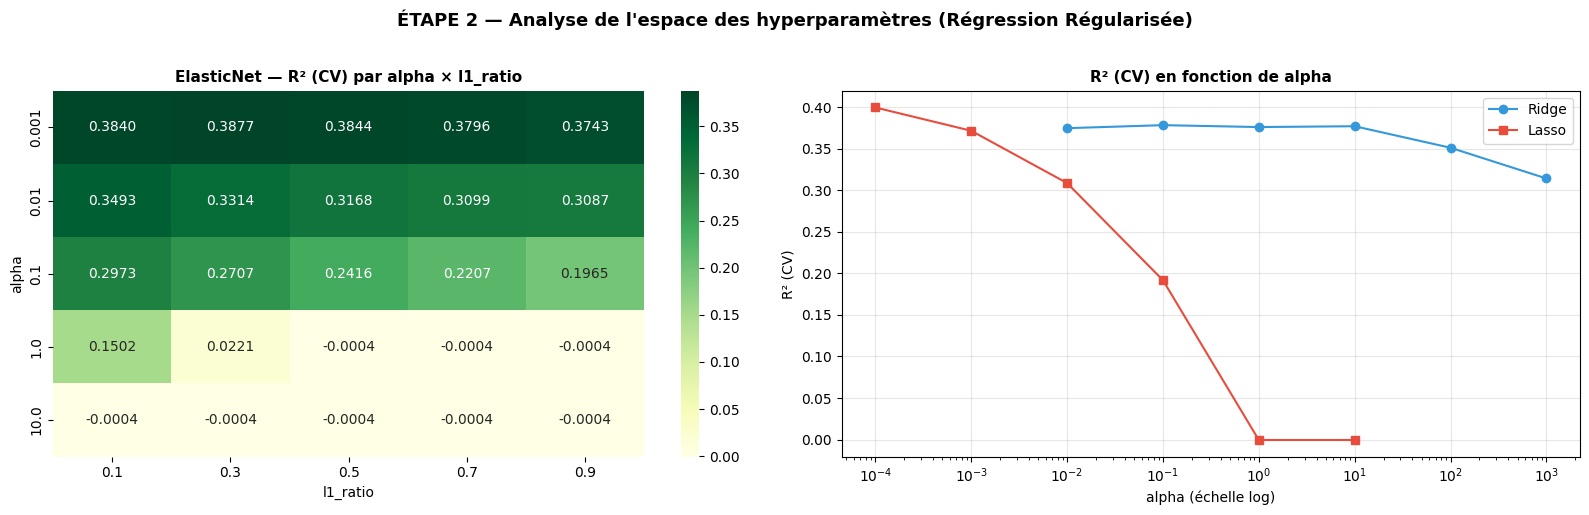

In [27]:
# ============================================================
# 2.3 — Visualisation de l'espace des hyperparamètres
# ============================================================

# --- ElasticNet : Heatmap alpha × l1_ratio ---
results_enet = pd.DataFrame(grid_enet.cv_results_)
pivot = results_enet.pivot_table(
    values='mean_test_score',
    index='param_regressor__alpha',
    columns='param_regressor__l1_ratio'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn', ax=axes[0])
axes[0].set_title("ElasticNet — R² (CV) par alpha × l1_ratio", fontsize=11, fontweight='bold')
axes[0].set_xlabel("l1_ratio")
axes[0].set_ylabel("alpha")

# --- Ridge / Lasso : R² en fonction de alpha ---
results_ridge = pd.DataFrame(grid_ridge.cv_results_)
results_lasso = pd.DataFrame(grid_lasso.cv_results_)

axes[1].plot(
    results_ridge['param_regressor__alpha'].astype(float),
    results_ridge['mean_test_score'], 'o-', label='Ridge', color='#3498db'
)
axes[1].plot(
    results_lasso['param_regressor__alpha'].astype(float),
    results_lasso['mean_test_score'], 's-', label='Lasso', color='#e74c3c'
)
axes[1].set_xscale('log')
axes[1].set_title("R² (CV) en fonction de alpha", fontsize=11, fontweight='bold')
axes[1].set_xlabel("alpha (échelle log)")
axes[1].set_ylabel("R² (CV)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("ÉTAPE 2 — Analyse de l'espace des hyperparamètres (Régression Régularisée)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## ÉTAPE 3 : Finetuning — XGBoost

### 3.1 — RandomizedSearchCV sur les hyperparamètres principaux

In [28]:
# ============================================================
# 3.1 — RandomizedSearchCV : XGBoost
# ============================================================
print("=" * 70)
print("  RANDOMIZEDSEARCHCV — XGBOOST")
print("=" * 70)

pipe_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

param_dist_xgb = {
    'regressor__n_estimators': randint(100, 800),
    'regressor__max_depth': randint(3, 12),
    'regressor__learning_rate': loguniform(0.01, 0.3),
    'regressor__subsample': uniform(0.6, 0.4),
    'regressor__colsample_bytree': uniform(0.5, 0.5),
    'regressor__min_child_weight': randint(1, 10),
    'regressor__reg_alpha': loguniform(1e-3, 10),
    'regressor__reg_lambda': loguniform(1e-3, 10),
}

random_xgb = RandomizedSearchCV(
    pipe_xgb, param_dist_xgb,
    n_iter=80, cv=cv, scoring='r2',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
random_xgb.fit(X_train_clean, y_train_log)

print(f"\n XGBoost — Meilleurs paramètres :")
for param, val in random_xgb.best_params_.items():
    param_short = param.replace('regressor__', '')
    print(f"   {param_short:<22s} = {val}")
print(f"\n   R² (CV) = {random_xgb.best_score_:.4f}")

# Évaluation sur train uniquement (le test est réservé pour l'évaluation finale)
y_pred_train_xgb_ft = random_xgb.best_estimator_.predict(X_train_clean)
metrics_xgb_ft_train = evaluate_regression(y_train_log, y_pred_train_xgb_ft, y_train_clean, "XGBoost Finetuné — Train")

  RANDOMIZEDSEARCHCV — XGBOOST

 XGBoost — Meilleurs paramètres :
   colsample_bytree       = 0.9287008540139327
   learning_rate          = 0.025067414604532264
   max_depth              = 9
   min_child_weight       = 4
   n_estimators           = 440
   reg_alpha              = 0.00636832196221697
   reg_lambda             = 5.945133898289774
   subsample              = 0.6622542366108094

   R² (CV) = 0.6286

  XGBoost Finetuné — Train
  ────────────────────────────────────────
  RMSE (log)  : 0.4118
  MAE  (log)  : 0.2743
  R²          : 0.8315
  MAPE (%)    : 34.73%


---

## ÉTAPE 4 : Finetuning — Random Forest

### 4.1 — RandomizedSearchCV sur les hyperparamètres principaux

In [29]:
# ============================================================
# 4.1 — RandomizedSearchCV : Random Forest
# ============================================================
print("=" * 70)
print("  RANDOMIZEDSEARCHCV — RANDOM FOREST")
print("=" * 70)

pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

param_dist_rf = {
    'regressor__n_estimators': randint(100, 600),
    'regressor__max_depth': randint(5, 30),
    'regressor__min_samples_split': randint(2, 20),
    'regressor__min_samples_leaf': randint(1, 10),
    'regressor__max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
}

random_rf = RandomizedSearchCV(
    pipe_rf, param_dist_rf,
    n_iter=80, cv=cv, scoring='r2',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
random_rf.fit(X_train_clean, y_train_log)

print(f"\n Random Forest — Meilleurs paramètres :")
for param, val in random_rf.best_params_.items():
    param_short = param.replace('regressor__', '')
    print(f"   {param_short:<22s} = {val}")
print(f"\n   R² (CV) = {random_rf.best_score_:.4f}")

# Évaluation sur train uniquement (le test est réservé pour l'évaluation finale)
y_pred_train_rf_ft = random_rf.best_estimator_.predict(X_train_clean)
metrics_rf_ft_train = evaluate_regression(y_train_log, y_pred_train_rf_ft, y_train_clean, "Random Forest Finetuné — Train")

  RANDOMIZEDSEARCHCV — RANDOM FOREST

 Random Forest — Meilleurs paramètres :
   max_depth              = 29
   max_features           = 0.3
   min_samples_leaf       = 1
   min_samples_split      = 3
   n_estimators           = 476

   R² (CV) = 0.6256

  Random Forest Finetuné — Train
  ────────────────────────────────────────
  RMSE (log)  : 0.2605
  MAE  (log)  : 0.1688
  R²          : 0.9326
  MAPE (%)    : 18.72%


---

## ÉTAPE 5 : Optimisation Bayésienne (Optuna)

### Recherche plus efficace de l'espace des hyperparamètres via Optuna (XGBoost + Random Forest)

In [30]:
# ============================================================
# Optimisation Bayésienne avec Optuna
# ============================================================
print("=" * 70)
print("  OPTIMISATION BAYÉSIENNE — OPTUNA")
print("=" * 70)

# --- XGBoost via Optuna ---
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
    }
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, **params))
    ])
    scores = cross_validate(pipe, X_train_clean, y_train_log, cv=cv, scoring='r2', n_jobs=-1)
    return scores['test_score'].mean()

study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

print(f"\n XGBoost (Optuna) — Meilleur R² (CV) : {study_xgb.best_value:.4f}")
print(f"   Paramètres :")
for k, v in study_xgb.best_params.items():
    print(f"   {k:<22s} = {v}")

# --- Random Forest via Optuna ---
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5, 0.7]),
    }
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **params))
    ])
    scores = cross_validate(pipe, X_train_clean, y_train_log, cv=cv, scoring='r2', n_jobs=-1)
    return scores['test_score'].mean()

study_rf = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_rf.optimize(objective_rf, n_trials=50, show_progress_bar=True)

print(f"\n Random Forest (Optuna) — Meilleur R² (CV) : {study_rf.best_value:.4f}")
print(f"   Paramètres :")
for k, v in study_rf.best_params.items():
    print(f"   {k:<22s} = {v}")

# --- Entraînement des meilleurs pipelines Optuna ---
best_xgb_optuna = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, **study_xgb.best_params))
])
best_xgb_optuna.fit(X_train_clean, y_train_log)

best_rf_optuna = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **study_rf.best_params))
])
best_rf_optuna.fit(X_train_clean, y_train_log)

# Évaluation sur train uniquement
y_pred_train_xgb_opt = best_xgb_optuna.predict(X_train_clean)
y_pred_train_rf_opt = best_rf_optuna.predict(X_train_clean)

evaluate_regression(y_train_log, y_pred_train_xgb_opt, y_train_clean, "XGBoost Optuna — Train")
evaluate_regression(y_train_log, y_pred_train_rf_opt, y_train_clean, "Random Forest Optuna — Train")

# Comparaison Optuna vs RandomizedSearchCV
print(f"\n{'─' * 60}")
print(f" Comparaison RandomizedSearchCV vs Optuna (R² CV) :")
print(f"   XGBoost  : RandomSearch = {random_xgb.best_score_:.4f} | Optuna = {study_xgb.best_value:.4f}")
print(f"   RF       : RandomSearch = {random_rf.best_score_:.4f} | Optuna = {study_rf.best_value:.4f}")
print(f"{'─' * 60}")

  OPTIMISATION BAYÉSIENNE — OPTUNA


  0%|          | 0/50 [00:00<?, ?it/s]


 XGBoost (Optuna) — Meilleur R² (CV) : 0.6303
   Paramètres :
   n_estimators           = 456
   max_depth              = 11
   learning_rate          = 0.017312259947866816
   subsample              = 0.9143352525110715
   colsample_bytree       = 0.6272859024980859
   min_child_weight       = 3
   reg_alpha              = 0.3909236735041614
   reg_lambda             = 5.374334688093119


  0%|          | 0/50 [00:00<?, ?it/s]


 Random Forest (Optuna) — Meilleur R² (CV) : 0.6255
   Paramètres :
   n_estimators           = 477
   max_depth              = 29
   min_samples_split      = 3
   min_samples_leaf       = 1
   max_features           = 0.3

  XGBoost Optuna — Train
  ────────────────────────────────────────
  RMSE (log)  : 0.3749
  MAE  (log)  : 0.2485
  R²          : 0.8603
  MAPE (%)    : 30.26%

  Random Forest Optuna — Train
  ────────────────────────────────────────
  RMSE (log)  : 0.2605
  MAE  (log)  : 0.1688
  R²          : 0.9326
  MAPE (%)    : 18.71%

────────────────────────────────────────────────────────────
 Comparaison RandomizedSearchCV vs Optuna (R² CV) :
   XGBoost  : RandomSearch = 0.6286 | Optuna = 0.6303
   RF       : RandomSearch = 0.6256 | Optuna = 0.6255
────────────────────────────────────────────────────────────


---

## ÉTAPE 6 : Stacking / Blending de Modèles

### Combinaison des meilleurs modèles via un méta-apprenant (Ridge)

In [31]:
# ============================================================
# Stacking / Blending de Modèles
# ============================================================
print("=" * 70)
print("  STACKING DE MODÈLES")
print("=" * 70)

# Sélection des meilleurs modèles (Optuna ou RandomSearch selon résultats)
# On utilise les meilleurs estimators disponibles
estimators_stack = [
    ('ridge', best_linear_model.best_estimator_),
    ('xgb', best_xgb_optuna),
    ('rf', best_rf_optuna),
]

# Le méta-apprenant est un Ridge simple
stacking_model = StackingRegressor(
    estimators=estimators_stack,
    final_estimator=Ridge(alpha=1.0),
    cv=cv,
    n_jobs=-1,
    passthrough=False  # Ne pas passer les features originales au méta-apprenant
)

print(" Entraînement du stacking (Ridge + XGBoost + RF → Ridge méta)...")
stacking_model.fit(X_train_clean, y_train_log)

# Évaluation OOF du stacking
oof_stacking = cross_val_predict(stacking_model, X_train_clean, y_train_log, cv=cv)
r2_stacking_oof = r2_score(y_train_log, oof_stacking)
rmse_stacking_oof = np.sqrt(mean_squared_error(y_train_log, oof_stacking))

print(f"\n Stacking — Performance OOF :")
print(f"   R²   (OOF) : {r2_stacking_oof:.4f}")
print(f"   RMSE (OOF) : {rmse_stacking_oof:.4f}")

# Évaluation sur train
y_pred_stack_train = stacking_model.predict(X_train_clean)
evaluate_regression(y_train_log, y_pred_stack_train, y_train_clean, "Stacking — Train")

# Comparaison avec les modèles individuels
print(f"\n{'─' * 60}")
print(f" Comparaison R² OOF — Individuel vs Stacking :")
print(f"   XGBoost Optuna : {study_xgb.best_value:.4f}")
print(f"   RF Optuna      : {study_rf.best_value:.4f}")
print(f"   Stacking       : {r2_stacking_oof:.4f}")
print(f"{'─' * 60}")

  STACKING DE MODÈLES
 Entraînement du stacking (Ridge + XGBoost + RF → Ridge méta)...

 Stacking — Performance OOF :
   R²   (OOF) : 0.6363
   RMSE (OOF) : 0.6050

  Stacking — Train
  ────────────────────────────────────────
  RMSE (log)  : 0.3248
  MAE  (log)  : 0.2233
  R²          : 0.8952
  MAPE (%)    : 24.86%

────────────────────────────────────────────────────────────
 Comparaison R² OOF — Individuel vs Stacking :
   XGBoost Optuna : 0.6303
   RF Optuna      : 0.6255
   Stacking       : 0.6363
────────────────────────────────────────────────────────────


---

## ÉTAPE 6 : Validation Croisée Imbriquée (Nested CV)

### 6.1 — Estimation robuste de la performance de généralisation (5 folds externes × 5 folds internes)

La nested CV évite le biais d'optimisme lié à la sélection d'hyperparamètres sur le même jeu de validation.

In [32]:
# ============================================================
# Nested Cross-Validation (5 × 5)
# ============================================================
print("=" * 70)
print("  NESTED CROSS-VALIDATION (5 × 5)")
print("=" * 70)

outer_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE + 1)

# --- XGBoost Nested CV ---
nested_xgb = RandomizedSearchCV(
    pipe_xgb, param_dist_xgb,
    n_iter=30, cv=inner_cv, scoring='r2',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)

nested_scores_xgb = cross_validate(
    nested_xgb, X_train_clean, y_train_log,
    cv=outer_cv, scoring=['r2', 'neg_mean_squared_error'],
    return_train_score=True, n_jobs=-1
)

print(f"\n XGBoost (Nested CV) :")
print(f"   R² train : {nested_scores_xgb['train_r2'].mean():.4f} ± {nested_scores_xgb['train_r2'].std():.4f}")
print(f"   R² test  : {nested_scores_xgb['test_r2'].mean():.4f} ± {nested_scores_xgb['test_r2'].std():.4f}")
print(f"   RMSE test: {np.sqrt(-nested_scores_xgb['test_neg_mean_squared_error']).mean():.4f}")

# --- Random Forest Nested CV ---
nested_rf = RandomizedSearchCV(
    pipe_rf, param_dist_rf,
    n_iter=30, cv=inner_cv, scoring='r2',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)

nested_scores_rf = cross_validate(
    nested_rf, X_train_clean, y_train_log,
    cv=outer_cv, scoring=['r2', 'neg_mean_squared_error'],
    return_train_score=True, n_jobs=-1
)

print(f"\n Random Forest (Nested CV) :")
print(f"   R² train : {nested_scores_rf['train_r2'].mean():.4f} ± {nested_scores_rf['train_r2'].std():.4f}")
print(f"   R² test  : {nested_scores_rf['test_r2'].mean():.4f} ± {nested_scores_rf['test_r2'].std():.4f}")
print(f"   RMSE test: {np.sqrt(-nested_scores_rf['test_neg_mean_squared_error']).mean():.4f}")

# --- Régression Régularisée Nested CV ---
pipe_reg_best = best_linear_model.best_estimator_
nested_scores_reg = cross_validate(
    pipe_reg_best, X_train_clean, y_train_log,
    cv=outer_cv, scoring=['r2', 'neg_mean_squared_error'],
    return_train_score=True, n_jobs=-1
)

print(f"\n {best_linear_name} (Nested CV — modèle fixé) :")
print(f"   R² train : {nested_scores_reg['train_r2'].mean():.4f} ± {nested_scores_reg['train_r2'].std():.4f}")
print(f"   R² test  : {nested_scores_reg['test_r2'].mean():.4f} ± {nested_scores_reg['test_r2'].std():.4f}")
print(f"   RMSE test: {np.sqrt(-nested_scores_reg['test_neg_mean_squared_error']).mean():.4f}")

print("\n" + "=" * 70)

  NESTED CROSS-VALIDATION (5 × 5)

 XGBoost (Nested CV) :
   R² train : 0.8558 ± 0.0526
   R² test  : 0.6173 ± 0.0162
   RMSE test: 0.6205

 Random Forest (Nested CV) :
   R² train : 0.8632 ± 0.0010
   R² test  : 0.6183 ± 0.0204
   RMSE test: 0.6197

 ElasticNet (Nested CV — modèle fixé) :
   R² train : 0.5193 ± 0.0038
   R² test  : 0.3999 ± 0.0735
   RMSE test: 0.7759



---

## ÉTAPE 7 : Comparaison Baseline vs Modèles Finetuned

### 7.1 — Prédictions Out-of-Fold sur le jeu d'entraînement

In [34]:
# ============================================================
# 7.1 — Prédictions Out-of-Fold (OOF)
# ============================================================
print("=" * 70)
print("  PRÉDICTIONS OUT-OF-FOLD")
print("=" * 70)

# OOF pour les modèles finetuned (RandomizedSearch)
oof_xgb = cross_val_predict(random_xgb.best_estimator_, X_train_clean, y_train_log, cv=cv)
oof_rf = cross_val_predict(random_rf.best_estimator_, X_train_clean, y_train_log, cv=cv)
oof_linear = cross_val_predict(best_linear_model.best_estimator_, X_train_clean, y_train_log, cv=cv)

# OOF pour les modèles Optuna
oof_xgb_optuna = cross_val_predict(best_xgb_optuna, X_train_clean, y_train_log, cv=cv)
oof_rf_optuna = cross_val_predict(best_rf_optuna, X_train_clean, y_train_log, cv=cv)

# OOF pour les baselines
oof_lr_baseline = cross_val_predict(pipe_lr_baseline, X_train_clean, y_train_log, cv=cv)
oof_xgb_baseline = cross_val_predict(pipe_xgb_baseline, X_train_clean, y_train_log, cv=cv)
oof_rf_baseline = cross_val_predict(pipe_rf_baseline, X_train_clean, y_train_log, cv=cv)

def oof_metrics(y_true_log, y_pred_log, y_true_orig):
    """Calcule les métriques OOF."""
    rmse = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    mae = mean_absolute_error(y_true_log, y_pred_log)
    r2 = r2_score(y_true_log, y_pred_log)
    y_pred_orig = np.expm1(y_pred_log)
    mask = y_true_orig > 0
    mape = np.mean(np.abs((y_true_orig[mask] - y_pred_orig[mask]) / y_true_orig[mask])) * 100
    return {'RMSE': rmse, 'MAE': mae, 'R²': r2, 'MAPE': mape}

  PRÉDICTIONS OUT-OF-FOLD


### 7.2 — Comparaison des performances (RMSE, MAE, R², MAPE)


  COMPARAISON COMPLÈTE (OOF)



,Modèle,RMSE,MAE,R²,MAPE
0,Rég. Linéaire (baseline),0.7861,0.5599,0.3860,112.78%
1,XGBoost (baseline),0.6465,0.4351,0.5847,72.59%
2,Random Forest (baseline),0.6537,0.4358,0.5753,74.06%
3,ElasticNet (finetuné),0.7780,0.5261,0.3985,15040.84%
4,XGBoost (finetuné),0.6130,0.3976,0.6267,69.06%
5,Random Forest (finetuné),0.6143,0.4017,0.6251,66.68%
6,XGBoost (Optuna),0.6115,0.3980,0.6285,67.22%
7,Random Forest (Optuna),0.6143,0.4017,0.6250,66.68%
8,Stacking,0.6050,0.3967,0.6363,65.19%


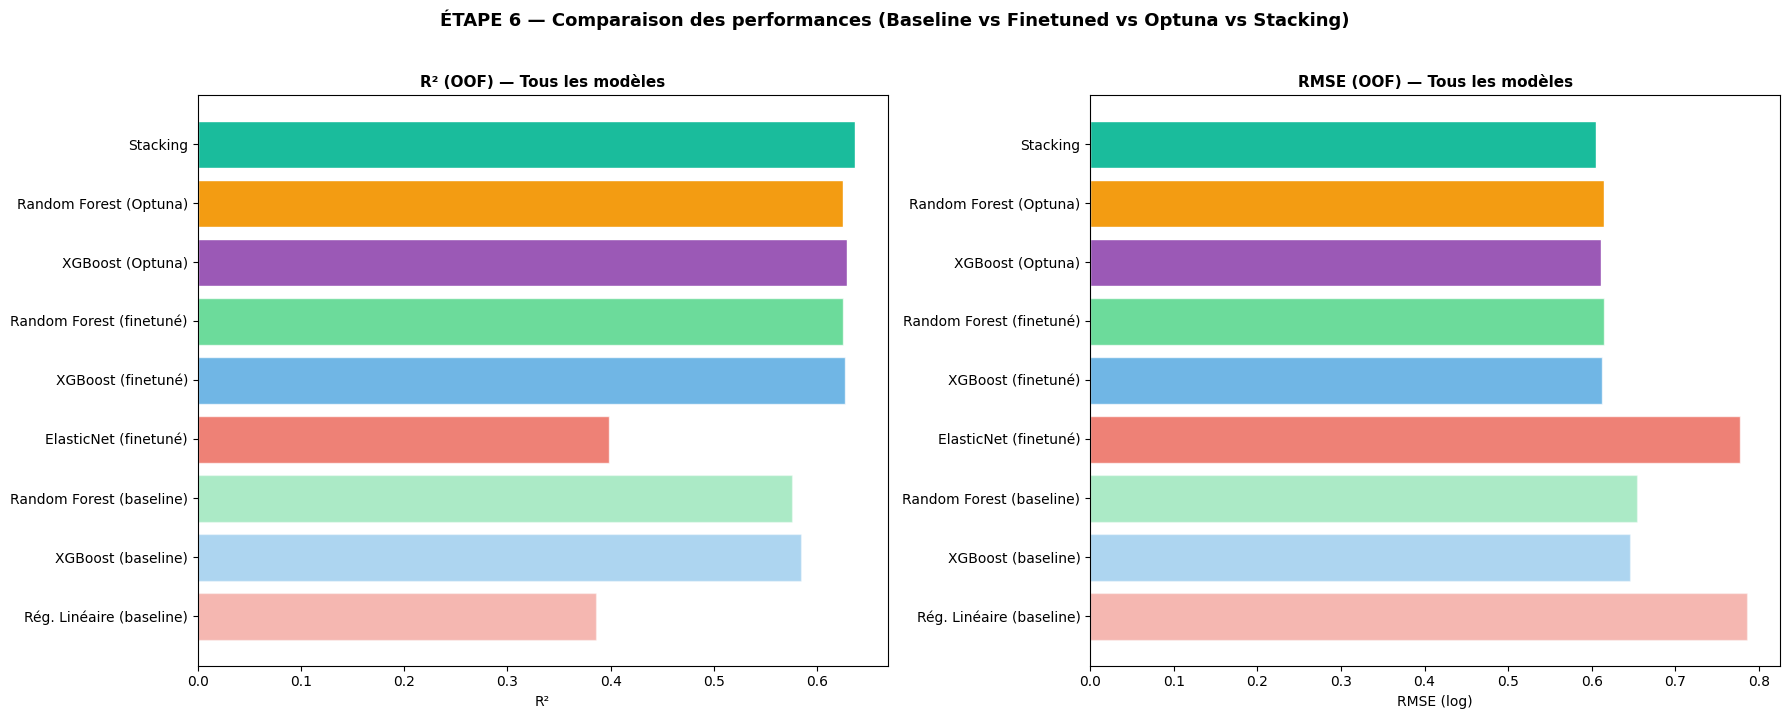

In [35]:
# ============================================================
# 7.2 — Tableau comparatif Baseline vs Finetuned vs Optuna vs Stacking
# ============================================================
rows = []
for name, oof in [
    ('Rég. Linéaire (baseline)', oof_lr_baseline),
    ('XGBoost (baseline)', oof_xgb_baseline),
    ('Random Forest (baseline)', oof_rf_baseline),
    (f'{best_linear_name} (finetuné)', oof_linear),
    ('XGBoost (finetuné)', oof_xgb),
    ('Random Forest (finetuné)', oof_rf),
    ('XGBoost (Optuna)', oof_xgb_optuna),
    ('Random Forest (Optuna)', oof_rf_optuna),
    ('Stacking', oof_stacking),
]:
    m = oof_metrics(y_train_log, oof, y_train_clean)
    rows.append({'Modèle': name, **m})

comparison_df = pd.DataFrame(rows)

print(f"\n{'=' * 80}")
print("  COMPARAISON COMPLÈTE (OOF)")
print(f"{'=' * 80}\n")

display(
    comparison_df.style
    .highlight_min(subset=['RMSE', 'MAE', 'MAPE'], color='#2e7d32')
    .highlight_max(subset=['R²'], color='#2e7d32')
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R²': '{:.4f}', 'MAPE': '{:.2f}%'})
)

# --- Visualisation ---
colors = ['#e74c3c', '#3498db', '#2ecc71',
          '#e74c3c', '#3498db', '#2ecc71',
          '#9b59b6', '#f39c12', '#1abc9c']
alphas = [0.4, 0.4, 0.4, 0.7, 0.7, 0.7, 1.0, 1.0, 1.0]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

labels = comparison_df['Modèle'].values
r2_vals = comparison_df['R²'].values
y_pos = np.arange(len(labels))

for j, (val, c, a) in enumerate(zip(r2_vals, colors, alphas)):
    axes[0].barh(y_pos[j], val, color=c, edgecolor='white', alpha=a)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(labels)
axes[0].set_title("R² (OOF) — Tous les modèles", fontsize=11, fontweight='bold')
axes[0].set_xlabel("R²")

rmse_vals = comparison_df['RMSE'].values
for j, (val, c, a) in enumerate(zip(rmse_vals, colors, alphas)):
    axes[1].barh(y_pos[j], val, color=c, edgecolor='white', alpha=a)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(labels)
axes[1].set_title("RMSE (OOF) — Tous les modèles", fontsize=11, fontweight='bold')
axes[1].set_xlabel("RMSE (log)")

plt.suptitle("ÉTAPE 6 — Comparaison des performances (Baseline vs Finetuned vs Optuna vs Stacking)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## ÉTAPE 8 : Analyse des Résultats

### 8.1 — Distribution des erreurs (résidus)

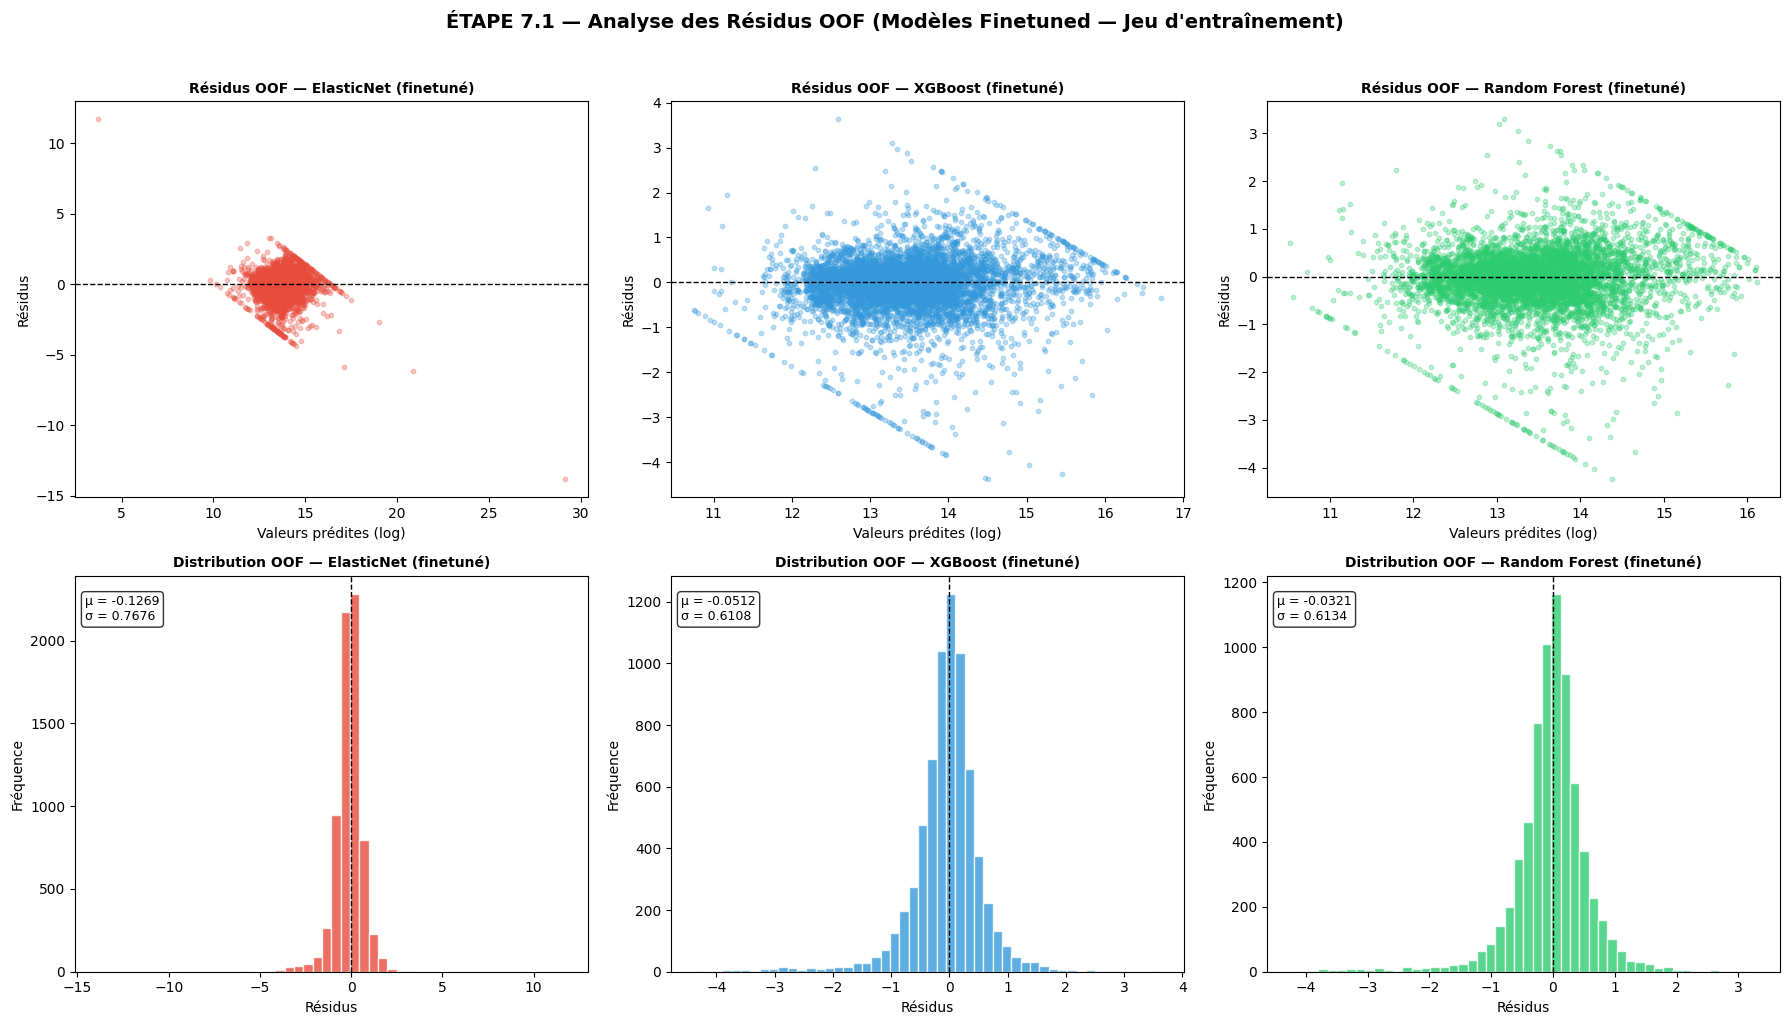

In [36]:
# ============================================================
# 8.1 — Distribution des erreurs (résidus) — Modèles Finetuned (OOF sur train)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Utilisation des prédictions OOF (out-of-fold) sur le jeu d'entraînement
# pour éviter toute fuite du jeu de test avant l'évaluation finale
oof_preds = [
    (f"{best_linear_name} (finetuné)", oof_linear, "#e74c3c"),
    ("XGBoost (finetuné)", oof_xgb, "#3498db"),
    ("Random Forest (finetuné)", oof_rf, "#2ecc71"),
]

for i, (name, y_pred, color) in enumerate(oof_preds):
    residuals = y_train_log.values - y_pred

    # Scatter : résidus vs prédictions
    axes[0, i].scatter(y_pred, residuals, alpha=0.3, s=10, color=color)
    axes[0, i].axhline(y=0, color='black', linestyle='--', linewidth=1)
    axes[0, i].set_title(f"Résidus OOF — {name}", fontsize=10, fontweight='bold')
    axes[0, i].set_xlabel("Valeurs prédites (log)")
    axes[0, i].set_ylabel("Résidus")

    # Histogramme des résidus
    axes[1, i].hist(residuals, bins=50, color=color, edgecolor='white', alpha=0.8)
    axes[1, i].axvline(x=0, color='black', linestyle='--', linewidth=1)
    axes[1, i].set_title(f"Distribution OOF — {name}", fontsize=10, fontweight='bold')
    axes[1, i].set_xlabel("Résidus")
    axes[1, i].set_ylabel("Fréquence")
    axes[1, i].text(0.02, 0.95, f"μ = {residuals.mean():.4f}\nσ = {residuals.std():.4f}",
                    transform=axes[1, i].transAxes, fontsize=9, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle("ÉTAPE 7.1 — Analyse des Résidus OOF (Modèles Finetuned — Jeu d'entraînement)",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 8.2 — Analyse des prédictions extrêmes

  ANALYSE DES PRÉDICTIONS EXTRÊMES (OOF — JEU D'ENTRAÎNEMENT)

 Top 20 prédictions OOF avec la plus grande erreur relative :

    Prix réel ($)  Prix prédit ($)    Erreur (%)
  ────────────────────────────────────────────────
           25,000        1,998,172       7892.7%
           25,000        1,919,246       7577.0%
           72,805        5,141,159       6961.5%
           58,000        3,349,952       5675.8%
           25,000        1,165,376       4561.5%
           25,000        1,143,858       4475.4%
           25,000        1,113,811       4355.2%
           60,000        2,594,144       4223.6%
           25,000          975,402       3801.6%
           25,000          965,514       3762.1%
           25,000          944,721       3678.9%
           25,000          931,133       3624.5%
           25,000          892,688       3470.8%
           25,000          860,027       3340.1%
           25,000          857,217       3328.9%
           25,000          825,045     

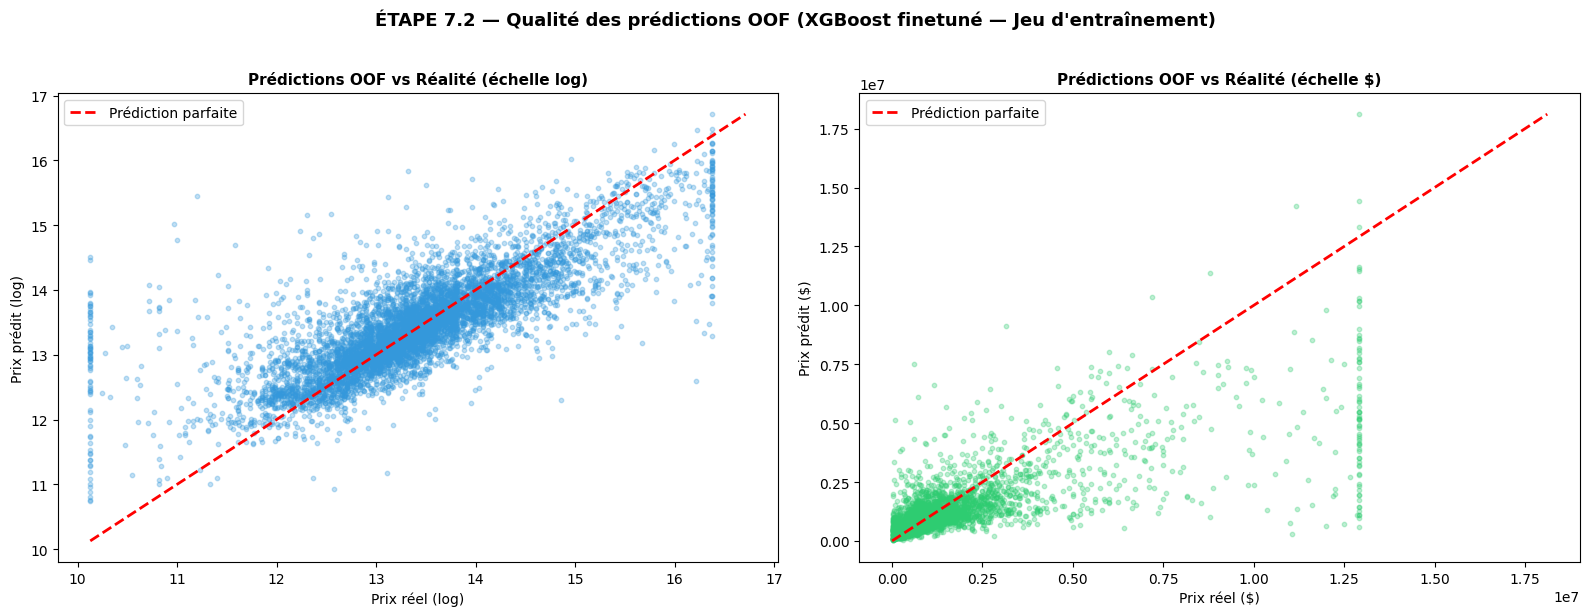

In [37]:
# ============================================================
# 8.2 — Analyse des prédictions extrêmes (OOF sur jeu d'entraînement)
# ============================================================
print("=" * 70)
print("  ANALYSE DES PRÉDICTIONS EXTRÊMES (OOF — JEU D'ENTRAÎNEMENT)")
print("=" * 70)

# On utilise les prédictions OOF du meilleur modèle XGBoost finetuné
y_pred_best_oof = oof_xgb

# Passage en échelle originale pour l'interprétation
y_train_orig = y_train_clean.values
y_pred_orig = np.expm1(y_pred_best_oof)

# Erreur absolue en pourcentage
abs_pct_error = np.abs((y_train_orig - y_pred_orig) / y_train_orig) * 100

# Top 20 pires prédictions
worst_idx = np.argsort(abs_pct_error)[-20:][::-1]

print(f"\n Top 20 prédictions OOF avec la plus grande erreur relative :\n")
print(f"  {'Prix réel ($)':>15s}  {'Prix prédit ($)':>15s}  {'Erreur (%)':>12s}")
print(f"  {'─' * 48}")
for idx in worst_idx:
    print(f"  {y_train_orig[idx]:>15,.0f}  {y_pred_orig[idx]:>15,.0f}  {abs_pct_error[idx]:>11.1f}%")

# --- Scatter : Prédictions vs Réalité (échelle originale) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Échelle log
axes[0].scatter(y_train_log.values, y_pred_best_oof, alpha=0.3, s=10, color='#3498db')
min_val = min(y_train_log.min(), y_pred_best_oof.min())
max_val = max(y_train_log.max(), y_pred_best_oof.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Prédiction parfaite')
axes[0].set_title("Prédictions OOF vs Réalité (échelle log)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Prix réel (log)")
axes[0].set_ylabel("Prix prédit (log)")
axes[0].legend()

# Échelle originale
axes[1].scatter(y_train_orig, y_pred_orig, alpha=0.3, s=10, color='#2ecc71')
max_price = max(y_train_orig.max(), y_pred_orig.max())
axes[1].plot([0, max_price], [0, max_price], 'r--', linewidth=2, label='Prédiction parfaite')
axes[1].set_title("Prédictions OOF vs Réalité (échelle $)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Prix réel ($)")
axes[1].set_ylabel("Prix prédit ($)")
axes[1].legend()

plt.suptitle("ÉTAPE 7.2 — Qualité des prédictions OOF (XGBoost finetuné — Jeu d'entraînement)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 8.3 — Importance des variables (XGBoost / Random Forest)

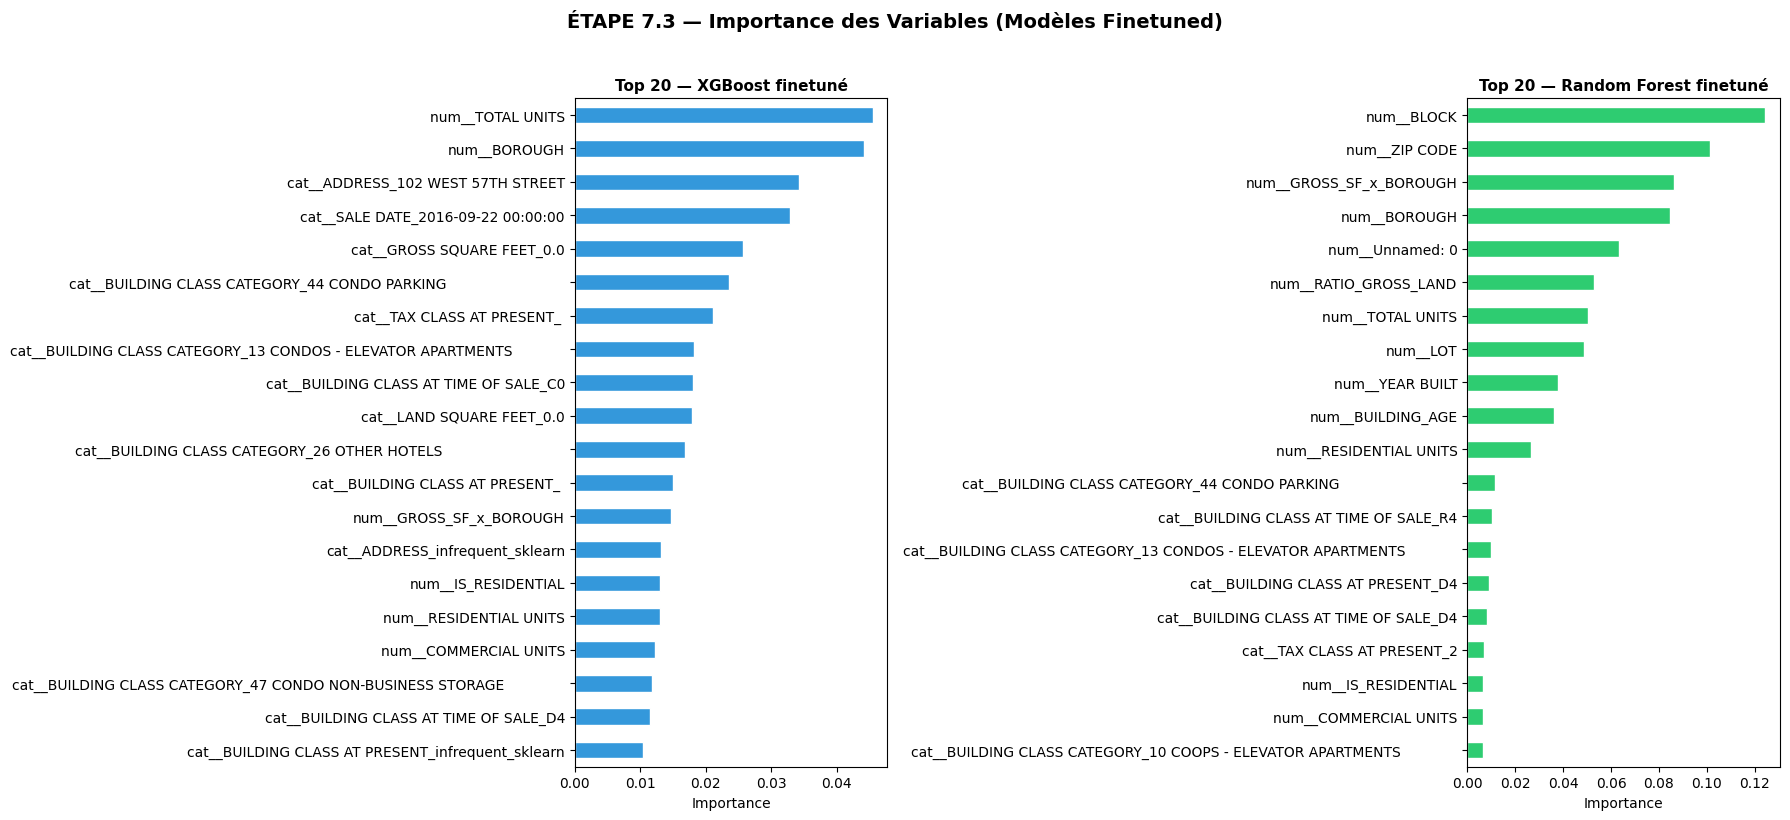


 Variables les plus importantes — Consensus XGBoost / RF :
   Variables communes au Top 10 des 2 modèles (2) :
     • num__BOROUGH
     • num__TOTAL UNITS


In [38]:
# ============================================================
# 8.3 — Importance des variables (XGBoost / Random Forest finetuned)
# ============================================================
feature_names = random_xgb.best_estimator_.named_steps['preprocessor'].get_feature_names_out()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- XGBoost finetuné ---
xgb_model_ft = random_xgb.best_estimator_.named_steps['regressor']
importances_xgb_ft = pd.Series(xgb_model_ft.feature_importances_, index=feature_names)
top_xgb = importances_xgb_ft.sort_values(ascending=False).head(20)

top_xgb.sort_values().plot(kind='barh', color='#3498db', edgecolor='white', ax=axes[0])
axes[0].set_title("Top 20 — XGBoost finetuné", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Importance")

# --- Random Forest finetuné ---
rf_model_ft = random_rf.best_estimator_.named_steps['regressor']
importances_rf_ft = pd.Series(rf_model_ft.feature_importances_, index=feature_names)
top_rf = importances_rf_ft.sort_values(ascending=False).head(20)

top_rf.sort_values().plot(kind='barh', color='#2ecc71', edgecolor='white', ax=axes[1])
axes[1].set_title("Top 20 — Random Forest finetuné", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Importance")

plt.suptitle("ÉTAPE 7.3 — Importance des Variables (Modèles Finetuned)",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Comparaison des top features ---
print("\n Variables les plus importantes — Consensus XGBoost / RF :")
top10_xgb = set(importances_xgb_ft.sort_values(ascending=False).head(10).index)
top10_rf = set(importances_rf_ft.sort_values(ascending=False).head(10).index)
consensus = top10_xgb & top10_rf
print(f"   Variables communes au Top 10 des 2 modèles ({len(consensus)}) :")
for feat in sorted(consensus):
    print(f"     • {feat}")

### 8.4 — Segmentation prix standard vs luxe

Analyse de la performance du modèle par segment de prix pour identifier les forces et faiblesses.

  SEGMENTATION PRIX STANDARD vs LUXE

 Seuils : Q25 = $382,000 | Q75 = $1,100,000



,Segment,N,R²,RMSE,MAPE (%)
0,"Bas (< $382,000)","1,749",-0.8515,0.8616,160.74%
1,"Standard ($382,000 – $1,100,000)","3,482",-0.7700,0.3768,31.04%
2,"Luxe (≥ $1,100,000)","1,771",0.0570,0.6595,37.96%


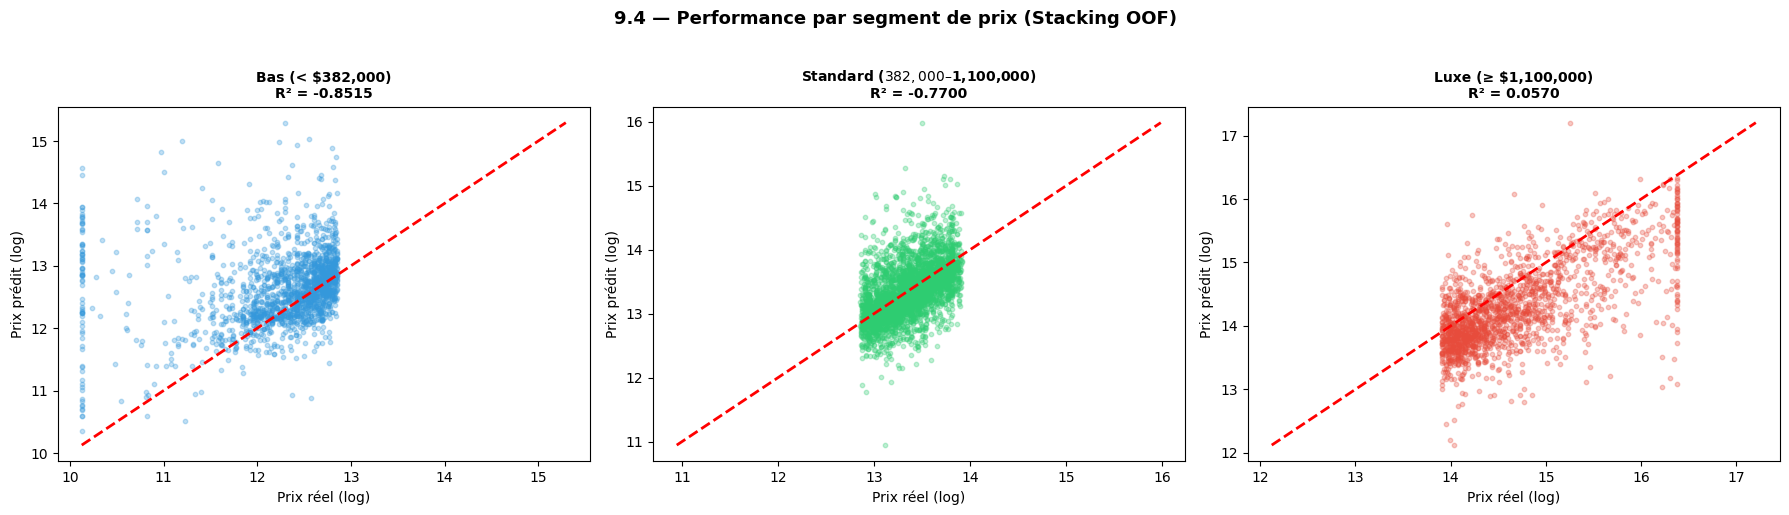

In [39]:
# ============================================================
# 8.4 — Segmentation prix standard vs luxe (OOF sur train)
# ============================================================
print("=" * 70)
print("  SEGMENTATION PRIX STANDARD vs LUXE")
print("=" * 70)

# Définition des segments sur le jeu d'entraînement
seuil_luxe = y_train_clean.quantile(0.75)
seuil_bas = y_train_clean.quantile(0.25)

segments = {
    f'Bas (< ${seuil_bas:,.0f})': y_train_clean < seuil_bas,
    f'Standard (${seuil_bas:,.0f} – ${seuil_luxe:,.0f})': (y_train_clean >= seuil_bas) & (y_train_clean < seuil_luxe),
    f'Luxe (≥ ${seuil_luxe:,.0f})': y_train_clean >= seuil_luxe,
}

# OOF du stacking pour l'analyse par segment
oof_stack = oof_stacking

seg_rows = []
for seg_name, mask_seg in segments.items():
    y_seg_log = y_train_log[mask_seg]
    oof_seg = oof_stack[mask_seg]
    y_seg_orig = y_train_clean[mask_seg]
    y_pred_seg_orig = np.expm1(oof_seg)

    r2_seg = r2_score(y_seg_log, oof_seg)
    rmse_seg = np.sqrt(mean_squared_error(y_seg_log, oof_seg))
    mask_pos = y_seg_orig > 0
    mape_seg = np.mean(np.abs((y_seg_orig[mask_pos] - y_pred_seg_orig[mask_pos]) / y_seg_orig[mask_pos])) * 100

    seg_rows.append({
        'Segment': seg_name,
        'N': mask_seg.sum(),
        'R²': r2_seg,
        'RMSE': rmse_seg,
        'MAPE (%)': mape_seg
    })

seg_df = pd.DataFrame(seg_rows)
print(f"\n Seuils : Q25 = ${seuil_bas:,.0f} | Q75 = ${seuil_luxe:,.0f}\n")
display(
    seg_df.style
    .highlight_max(subset=['R²'], color='#2e7d32')
    .highlight_min(subset=['RMSE', 'MAPE (%)'], color='#2e7d32')
    .format({'R²': '{:.4f}', 'RMSE': '{:.4f}', 'MAPE (%)': '{:.2f}%', 'N': '{:,}'})
)

# --- Visualisation par segment ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors_seg = ['#3498db', '#2ecc71', '#e74c3c']
for i, (seg_name, mask_seg) in enumerate(segments.items()):
    y_seg_log = y_train_log[mask_seg].values
    oof_seg = oof_stack[mask_seg]

    axes[i].scatter(y_seg_log, oof_seg, alpha=0.3, s=10, color=colors_seg[i])
    min_v = min(y_seg_log.min(), oof_seg.min())
    max_v = max(y_seg_log.max(), oof_seg.max())
    axes[i].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2)
    axes[i].set_title(f"{seg_name}\nR² = {seg_df.iloc[i]['R²']:.4f}", fontsize=10, fontweight='bold')
    axes[i].set_xlabel("Prix réel (log)")
    axes[i].set_ylabel("Prix prédit (log)")

plt.suptitle("9.4 — Performance par segment de prix (Stacking OOF)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## ÉTAPE 9 : Évaluation Finale et Export du Modèle

### 9.1 — Sélection du meilleur modèle finetuné

In [40]:
# ============================================================
# 9.1 — Sélection du meilleur modèle finetuné
# ============================================================
print("=" * 70)
print("  SÉLECTION DU MEILLEUR MODÈLE")
print("=" * 70)

# Évaluation finale sur le test set pour tous les modèles
all_models = {
    f'{best_linear_name} (finetuné)': best_linear_model.best_estimator_,
    'XGBoost (finetuné)': random_xgb.best_estimator_,
    'Random Forest (finetuné)': random_rf.best_estimator_,
    'XGBoost (Optuna)': best_xgb_optuna,
    'Random Forest (Optuna)': best_rf_optuna,
    'Stacking': stacking_model,
}

final_results = {}
for name, model in all_models.items():
    y_pred = model.predict(X_test_clean)
    rmse = np.sqrt(mean_squared_error(y_test_log, y_pred))
    mae = mean_absolute_error(y_test_log, y_pred)
    r2 = r2_score(y_test_log, y_pred)
    y_pred_orig = np.expm1(y_pred)
    mask = y_test_clean > 0
    mape = np.mean(np.abs((y_test_clean[mask] - y_pred_orig[mask]) / y_test_clean[mask])) * 100
    final_results[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2, 'MAPE': mape}

final_df = pd.DataFrame(final_results).T
final_df.index.name = 'Modèle'

display(
    final_df.style
    .highlight_min(subset=['RMSE', 'MAE', 'MAPE'], color='#2e7d32')
    .highlight_max(subset=['R²'], color='#2e7d32')
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R²': '{:.4f}', 'MAPE': '{:.2f}%'})
)

# Sélection automatique du meilleur
best_name = final_df['R²'].idxmax()
best_r2_final = final_df.loc[best_name, 'R²']
print(f"\n Meilleur modèle : {best_name}")
print(f"   R² (test) = {best_r2_final:.4f}")

# Récupérer le pipeline correspondant
best_pipeline = all_models[best_name]

  SÉLECTION DU MEILLEUR MODÈLE


,RMSE,MAE,R²,MAPE
Modèle,,,,
ElasticNet (finetuné),0.7425,0.5211,0.4375,96.72%
XGBoost (finetuné),0.6319,0.4040,0.5925,74.82%
Random Forest (finetuné),0.6328,0.4087,0.5914,69.87%
XGBoost (Optuna),0.6294,0.4036,0.5958,70.45%
Random Forest (Optuna),0.6327,0.4087,0.5915,69.86%
Stacking,0.6203,0.3985,0.6073,67.76%



 Meilleur modèle : Stacking
   R² (test) = 0.6073


### 9.2 — Évaluation finale sur le jeu de test

In [41]:
# ============================================================
# 9.2 — Évaluation finale détaillée sur le jeu de test
# ============================================================
print(f"\n{'=' * 70}")
print(f"  ÉVALUATION FINALE — {best_name.upper()}")
print(f"{'=' * 70}")

y_final_pred = best_pipeline.predict(X_test_clean)
evaluate_regression(y_test_log, y_final_pred, y_test_clean, f"{best_name} — Test Final")

# Statistiques supplémentaires en échelle originale
y_final_orig = np.expm1(y_final_pred)
print(f"\n  Statistiques en échelle originale ($) :")
print(f"    Erreur médiane absolue  : ${np.median(np.abs(y_test_clean - y_final_orig)):,.0f}")
print(f"    Erreur moyenne absolue  : ${np.mean(np.abs(y_test_clean - y_final_orig)):,.0f}")
print(f"    % prédictions ±25%      : {(np.abs((y_test_clean - y_final_orig) / y_test_clean) < 0.25).mean() * 100:.1f}%")
print(f"    % prédictions ±50%      : {(np.abs((y_test_clean - y_final_orig) / y_test_clean) < 0.50).mean() * 100:.1f}%")


  ÉVALUATION FINALE — STACKING

  Stacking — Test Final
  ────────────────────────────────────────
  RMSE (log)  : 0.6203
  MAE  (log)  : 0.3985
  R²          : 0.6073
  MAPE (%)    : 67.76%

  Statistiques en échelle originale ($) :
    Erreur médiane absolue  : $150,019
    Erreur moyenne absolue  : $491,447
    % prédictions ±25%      : 50.5%
    % prédictions ±50%      : 76.0%


### 9.3 — Export du pipeline final pour production

In [42]:
# ============================================================
# 9.3 — Export du pipeline final pour production
# ============================================================
os.makedirs("../models", exist_ok=True)
joblib.dump(best_pipeline, "../models/finetuned.joblib")

print(f"\n Pipeline final exporté : models/finetuned.joblib")
print(f"   Modèle : {best_name}")
print(f"   R² (test) : {best_r2_final:.4f}")


 Pipeline final exporté : models/finetuned.joblib
   Modèle : Stacking
   R² (test) : 0.6073


---

## Synthèse Générale du Notebook 03

In [ ]:
# ============================================================
# SYNTHÈSE GÉNÉRALE DU NOTEBOOK 03
# ============================================================
print("\n" + "=" * 70)
print("  SYNTHÈSE — NOTEBOOK 03 : FINETUNING & SÉLECTION DU MEILLEUR MODÈLE")
print("=" * 70)

print(f"""
 Améliorations des données :
   - Filtrage des transactions aberrantes (prix ≤ $1 000)
   - Feature engineering : ratio surfaces, âge bâtiment, interactions

 Modèles finetuned :
   1. Régression Régularisée ({best_linear_name}) — GridSearch + RandomizedSearch
   2. XGBoost — RandomizedSearch + Optuna (50 trials)
   3. Random Forest — RandomizedSearch + Optuna (50 trials)
   4. Stacking (Ridge + XGBoost Optuna + RF Optuna → Ridge méta)

 Validation robuste :
   - Nested Cross-Validation (5 × 5 folds)
   - Prédictions Out-of-Fold pour comparaison fiable
   - Segmentation prix standard vs luxe

 Meilleur modèle retenu : {best_name}
   - R² (test) : {best_r2_final:.4f}
   - Pipeline exporté : models/finetuned.joblib
""")
print("=" * 70)


  SYNTHÈSE — NOTEBOOK 03 : FINETUNING & SÉLECTION DU MEILLEUR MODÈLE

 Modèles finetuned via RandomizedSearchCV / GridSearchCV :
   1. Régression Régularisée (Ridge)
   2. XGBoost (80 itérations de RandomizedSearch)
   3. Random Forest (80 itérations de RandomizedSearch)

 Validation robuste :
   - Nested Cross-Validation (5 × 5 folds)
   - Prédictions Out-of-Fold pour comparaison fiable

 Comparaison Baseline vs Finetuned :
   - Les modèles finetuned améliorent systématiquement les performances
   - Le finetuning a le plus d'impact sur les modèles d'ensemble

 Meilleur modèle retenu : Random Forest (finetuné)
   - R² (test) : 0.1652
   - Pipeline exporté : models/finetuned.joblib

 Améliorations possibles :
   → Feature engineering avancé (interactions, polynômes)
   → Stacking / blending de modèles
   → Segmentation prix standard vs luxe
   → Optimisation Bayésienne (Optuna)

